# Using Different bacpipe Functions

This notebook is a collection of short, mostly independent code blocks that
demonstrate the individual building blocks of `bacpipe`, complementing the
end-to-end workflow in `simple_use_cases.ipynb`. Every object that `bacpipe`
exposes at the top level (`bacpipe.__all__`) is shown here in a small,
self-contained snippet, so you can copy any cell and adapt it to your own use
case.

Most cells only depend on the **Setup & Configuration** cell below. A few
evaluation cells additionally reuse the embeddings computed in the
*Generating Embeddings* section; those dependencies are called out in the
section text.


Make sure to reset your config and settings files before running this notebook, 
as they may contain settings from previous runs that could prevent this notebook 
from finding the correct paths.

---

**Contents**

1. [Setup & Configuration](#1.-Setup-&-Configuration)
2. [Constants](#2.-Constants)
3. [Folder Structure & Paths](#3.-Folder-Structure-&-Paths)
4. [Model Utilities](#4.-Model-Utilities)
5. [Audio Handling](#5.-Audio-Handling)
6. [Embeddings from Audio](#6.-Embeddings-from-Audio)
7. [Generating Embeddings](#7.-Generating-Embeddings)
8. [Custom Metadata Labels](#8.-Custom-Metadata-Labels)
9. [Model-Specific Evaluation](#9.-Model-Specific-Evaluation)
10. [Probing](#10.-Probing)
11. [Clustering](#11.-Clustering)
12. [Benchmarking](#12.-Benchmarking)
13. [Cross-Model Evaluation](#13.-Cross-Model-Evaluation)
14. [Dashboard & play](#14.-Dashboard-&-play)


---
## 1. Setup & Configuration

Set the working directory to the repo root, import the display utilities and
point bacpipe at a dedicated results folder so this tutorial does not
interfere with the others.

In [1]:
# to run successfully the packages for jupyter notebook need to be installed:
# uv pip install ipykernel, ipython

from IPython.display import display, Image
from PIL import Image as PILImage
import os
import shutil
from pathlib import Path

import importlib.resources as pkg_resources
import numpy as np
import pandas as pd

os.chdir(pkg_resources.files("bacpipe"))
os.chdir('..')

# load the specific package
import bacpipe

# Store the results of this tutorial in a dedicated subfolder so they do not
# interfere with the other tutorials.
bacpipe.settings.main_results_dir = str(
    Path(bacpipe.settings.main_results_dir) / 'using_different_bacpipe_functions'
)

# Keep the tutorial reproducible on any machine.
bacpipe.settings.device = 'cpu'

# !WARNING! the following code deletes the folder where the results of this
# tutorial are stored, to make sure every run starts from a clean folder.
# Comment this out if you have important data in this folder.
shutil.rmtree(bacpipe.settings.main_results_dir, ignore_errors=True)

print('Results will be stored in:', bacpipe.settings.main_results_dir)


def show_half(path):
    # Display a saved plot at half its original size.
    with PILImage.open(path) as img:
        w, _ = img.size
    display(Image(filename=str(path), width=w // 2))


/home/siriussound/Code/testing_repos/bacpipe/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/siriussound/Code/testing_repos/bacpipe/bacpipe/embedding_evaluation/visualization/dashboard.py:42: UserWarning: Using Panel interactively in VSCode notebooks requires the jupyter_bokeh package to be installed. You can install it with:

   pip install jupyter_bokeh

or:
    conda install jupyter_bokeh

and try again.
  pn.extension("plotly")


Results will be stored in: bacpipe_results/using_different_bacpipe_functions


---
## 2. Constants

`bacpipe` re-exports a few module-level constants that describe which models
are supported and which ones need a checkpoint to be downloaded.

In [2]:
print('supported_models ({}):'.format(len(bacpipe.supported_models)))
print(bacpipe.supported_models)

print()
print('models_needing_checkpoint:')
print(bacpipe.models_needing_checkpoint)

print()
print('TF_MODELS:')
print(bacpipe.TF_MODELS)

print()
print('EMBEDDING_DIMENSIONS (first 6):')
print(dict(list(bacpipe.EMBEDDING_DIMENSIONS.items())[:6]))

print()
print('NEEDS_CHECKPOINT:')
print(bacpipe.NEEDS_CHECKPOINT)


supported_models (26):
['audiomae', 'audioprotopnet', 'avesecho_passt', 'aves_especies', 'bat', 'batdetect2_clip_avg', 'batdetect2_dets_avg', 'beats', 'birdaves_especies', 'biolingual', 'birdnet_v3', 'birdnet', 'birdmae', 'convnext_birdset', 'hbdet', 'insect66', 'insect459', 'mix2', 'naturebeats', 'perch_bird', 'perch_v2', 'protoclr', 'rcl_fs_bsed', 'surfperch', 'google_whale', 'vggish']

models_needing_checkpoint:
['audiomae', 'avesecho_passt', 'aves_especies', 'bat', 'beats', 'birdaves_especies', 'birdnet_v3', 'birdnet', 'hbdet', 'insect66', 'insect459', 'mix2', 'naturebeats', 'perch_v2', 'protoclr', 'rcl_fs_bsed']

TF_MODELS:
['birdnet', 'perch_bird', 'google_whale', 'surfperch', 'vggish', 'hbdet']

EMBEDDING_DIMENSIONS (first 6):
{'audiomae': 768, 'audioprotopnet': 1024, 'avesecho_passt': 768, 'aves_especies': 768, 'bat': 64, 'batdetect2_clip_avg': 32}

NEEDS_CHECKPOINT:
['audiomae', 'avesecho_passt', 'aves_especies', 'bat', 'beats', 'birdaves_especies', 'birdnet_v3', 'birdnet', 'h

---
## 3. Folder Structure & Paths

Every artifact bacpipe produces (embeddings, labels, probing and clustering
results, plots, ...) is stored in a deterministic folder structure. The layout
is exposed through a lightweight `get_paths` function returned by
`make_set_paths_func`.

In [3]:
get_paths = bacpipe.make_set_paths_func(
    'bacpipe/tests/test_data',
    main_results_dir=bacpipe.settings.main_results_dir,
)

paths = get_paths('birdnet')

for attr in ['dataset_path', 'main_embeds_path', 'labels_path',
             'probe_path', 'clust_path', 'preds_path', 'plot_path']:
    print(f'{attr:<20} {getattr(paths, attr)}')


dataset_path         bacpipe_results/using_different_bacpipe_functions/test_data
main_embeds_path     bacpipe_results/using_different_bacpipe_functions/test_data/embeddings
labels_path          bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/labels
probe_path           bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/probing
clust_path           bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/clustering
preds_path           bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/predictions
plot_path            bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/plots


In [4]:
# Check whether the full evaluation (embeddings, dimensionality reduction,
# probing and clustering) already exists for a given model/dataset
# combination. This is False on a fresh run and True once the sections below
# have completed.
already_exists = bacpipe.evaluation_with_settings_already_exists(
    audio_dir='bacpipe/tests/test_data',
    dim_reduction_model='umap',
    models=['birdnet', 'insect459'],
)
print('Evaluation already exists:', already_exists)


Evaluation already exists: False


---
## 4. Model Utilities

Before any processing, make sure the model checkpoints are available locally
and confirm that the requested model names are supported.

In [5]:
model_base_path = bacpipe.ensure_models_exist(
    bacpipe.settings.model_base_path,
    model_names=['birdnet', 'insect459'],
)
print('Model checkpoints are stored in:', model_base_path)

for model in ['birdnet', 'insect459']:
    print(f'{model} -> {bacpipe.confirm_model_name(model)}')

# get_model_names() either resolves a list of model names against the
# supported models or, with already_computed=True, infers them from the
# embeddings that already exist on disk.
model_names = bacpipe.get_model_names(
    models=['birdnet', 'insect459'],
    audio_dir='bacpipe/tests/test_data',
    main_results_dir=bacpipe.settings.main_results_dir,
    embed_parent_dir=bacpipe.settings.embed_parent_dir,
)
print('Resolved model names:', model_names)


Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.

insect459 checkpoint exists.



Model checkpoints are stored in: bacpipe_model_checkpoints
birdnet -> birdnet
insect459 -> insect459
Resolved model names: ['birdnet', 'insect459']


---
## 5. Audio Handling

`AudioHandler` loads and windows audio the way the selected model needs it.
It only needs the sample rate and the segment length of a model, so passing the
*name* of a supported model is enough -- the model itself (and with it its
checkpoint) is only loaded once the model specific preprocessing is applied in
`prepare_audio()`. A model object (`Embedder(...).model`) can be passed just as
well.

There are two ways to load audio:

1. **whole files**, via `load_and_resample()` + `window_audio()`, and
2. **only the annotated segments**, via `only_load_annotated_segments()`.

In [6]:
from bacpipe import get_audio_files, AudioHandler

# (1) Whole-file loading: resample to the model sample rate, then window the
# audio into the fixed-length windows the model expects. Passing the model
# name is enough here, no checkpoint is loaded for this.
aud = AudioHandler(model='birdnet', audio_dir='bacpipe/tests/test_data')
print('birdnet expects {} Hz and {} samples per window.'.format(
    aud.model.sr, aud.model.segment_length))

files = get_audio_files('bacpipe/tests/test_data')

all_frames = []
for audio_file in files:
    audio, sr = aud.load_and_resample(audio_file)
    frames = aud.window_audio(audio)
    all_frames.extend(frames)
all_frames = np.stack(all_frames)
print('Windowed audio shape (n_windows, window_length):', all_frames.shape)


2026-08-26 16:38:55.539947: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-26 16:38:55.579966: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


birdnet expects 48000 Hz and 144000 samples per window.


finding audio files: 11it [00:00, 26949.38it/s]
Found 7 number of audio files.


Windowed audio shape (n_windows, window_length): (63, 144000)


In [7]:
# (2) Annotated-segment loading: extract just the time spans covered by the
# annotations file instead of a regular time grid.
aud_annotated = AudioHandler(
    model='birdnet',
    audio_dir='bacpipe/tests/test_data',
    only_embed_annotations=True,
)

all_annotated_frames = []
for audio_file in files:
    frames = aud_annotated.only_load_annotated_segments(audio_file)
    all_annotated_frames.extend(frames)
all_annotated_frames = np.stack(all_annotated_frames)
print('Annotated segments shape (n_segments, segment_length):',
      all_annotated_frames.shape)


Annotated segments shape (n_segments, segment_length): (37, 144000)


### Deviating from the model defaults

The sample rate and the segment length that were read from the model can be
changed at any time by setting `aud.model.sr` and `aud.model.segment_length`.
The audio is then loaded and windowed exactly the way you asked for, and the
values are kept when the model itself is loaded later on, so the segments are
preprocessed the way they were loaded.

In [8]:
# Load the audio at 32 kHz and window it into 3 second segments instead of
# the 48 kHz / 3 second windows birdnet uses by default.
aud.model.sr = 32_000
aud.model.segment_length = 3 * aud.model.sr

all_frames = []
for audio_file in files:
    audio, sr = aud.load_and_resample(audio_file)
    frames = aud.window_audio(audio)
    all_frames.extend(frames)
all_frames = np.stack(all_frames)
print('3 s windows at 32 kHz (n_windows, window_length):', all_frames.shape)


3 s windows at 32 kHz (n_windows, window_length): (63, 96000)


### Passing your own annotations to the audio handler

`only_load_annotated_segments()` reads `annotations.csv` from the audio
directory by default. Your own annotations can be passed as a dataframe
instead: only the segments it annotates are returned, everything else in the
recordings is ignored. If the dataframe has an `audiofilename` column it is
filtered down to the current file, so the whole table can be passed for every
file, and time windows that several rows share (e.g. two species in one
window) are loaded once.

In [9]:
import pandas as pd

annots = pd.read_csv('bacpipe/tests/test_data/annotations.csv')
# only keep the annotations of the first 10 seconds of every recording
annots = annots[annots.start < 10]
print('Annotations that are kept:', len(annots))

all_annotated_frames = []
for audio_file in files:
    frames = aud_annotated.only_load_annotated_segments(
        audio_file, annotations_df=annots
    )
    all_annotated_frames.extend(frames)
all_annotated_frames = np.stack(all_annotated_frames)
print('Segments annotated in the dataframe (n_segments, segment_length):',
      all_annotated_frames.shape)


Annotations that are kept: 14
Segments annotated in the dataframe (n_segments, segment_length): (14, 144000)


---
## 6. Embeddings from Audio

`Embedder` accepts just a model name and computes embeddings directly from an
audio file through `get_embeddings_from_model()`.

In [10]:
embed_obj = bacpipe.Embedder(model_name='birdnet')
audio_files = bacpipe.get_audio_files('bacpipe/tests/test_data')

all_embeds = []
for audio_file in audio_files:
    embeds = embed_obj.get_embeddings_from_model(audio_file)
    all_embeds.extend(embeds)
all_embeds = np.stack(all_embeds)
print('Embeddings shape (n_segments, n_dimensions):', all_embeds.shape)


Using device='cpu'
2026-08-26 16:38:57.836555: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-08-26 16:38:57.836579: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2026-08-26 16:38:57.836584: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2026-08-26 16:38:57.836588: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-08-26 16:38:57.836591: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: sirius-device
2026-08-26 16:38:57.836593: I external/local_xla/xla/s

Embeddings shape (n_segments, n_dimensions): (63, 1024)


---
## 7. Generating Embeddings

The same machinery is exposed at three levels: `generate_embeddings` (one
model, embeddings only), `run_pipeline_for_single_model` (one model, full
pipeline incl. classifier and dimensionality reduction) and
`run_pipeline_for_models` (several models, returns a dictionary of loaders).

`Loader` objects are returned by all three and give access to the embeddings
and metadata.

In [11]:
# generate_embeddings(): single-model embedding generation. With
# check_if_already_processed=True (the default) it reuses existing results.
loader = bacpipe.generate_embeddings(
    model_name='birdnet',
    audio_dir='bacpipe/tests/test_data',
    check_if_already_processed=True,
)

# Loader.embeddings() returns a dict mapping file stems to numpy arrays ...
embeds_dict = loader.embeddings()
print('Embeddings per file:', {k: v.shape for k, v in embeds_dict.items()})
# ... or a single numpy array of shape (n_segments, n_dimensions).
print('Embeddings array:', loader.embeddings(return_type='array').shape)


Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.




###### Generating embeddings using BIRDNET ######

finding audio files: 11it [00:00, 28585.71it/s]
Found 7 number of audio files.
Using device='cpu'
Skipping model.eval() because model is from tensorflow.
 processing batches: 100%|██████████| 5/5 [00:01<00:00,  5.02it/s]2026-08-26 16:39:04.601670: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Embeddings per file: {'audio/FewShot/CHE_01_20190101_163410_birdnet.npy': (22, 1024), 'audio/FewShot/CHE_02_20190101_183410_birdnet.npy': (4, 1024), 'audio/FewShot/CHE_03_20190201_163410_birdnet.npy': (3, 1024), 'audio/FewShot/CHE_04_20190203_175410_birdnet.npy': (4, 1024), 'audio/UrbanSoundscape/242A2604603691DD_20250503_031300_birdnet.npy': (10, 1024), 'audio/UrbanSoundscape/242A2604603691DD_20250503_031400_birdnet.npy': (10, 1024), 'audio/UrbanSoundscape/242A2604603691DD_20250503_031500_birdnet.npy': (10, 1024)}
Embeddings array: (63, 1024)


In [12]:
# run_pipeline_for_single_model(): full pipeline for one model. Set
# check_if_already_processed=False to force recomputation.
loader = bacpipe.run_pipeline_for_single_model(
    model_name='birdnet',
    audio_dir='bacpipe/tests/test_data',
    dim_reduction_model='None',
    check_if_already_processed=False,
)
print('Embeddings array shape:', loader.embeddings(return_type='array').shape)


Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.




###### Generating embeddings using BIRDNET ######

finding audio files: 11it [00:00, 31818.86it/s]
Found 7 number of audio files.
Using device='cpu'
Skipping model.eval() because model is from tensorflow.
 processing batches: 100%|██████████| 1/1 [00:00<00:00,  4.42it/s]2026-08-26 16:39:09.293403: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
                                                                  

Embeddings array shape: (63, 1024)


In [13]:
# run_pipeline_for_models(): several models at once. Passing
# dim_reduction_model='umap' additionally computes a 2D projection of each
# embedding space, which is used for the cross-model comparison in section 13.
loader_dict = bacpipe.run_pipeline_for_models(
    models=['birdnet', 'insect459'],
    audio_dir='bacpipe/tests/test_data',
    dim_reduction_model='umap',
)

for model, loader in loader_dict.items():
    print(model, '->', loader.embeddings(return_type='array').shape)


Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.




###### Generating embeddings using BIRDNET ######

finding audio files: 11it [00:00, 22149.47it/s]
Found 7 number of audio files.
Using device='cpu'
Skipping model.eval() because model is from tensorflow.
                                                                  Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.




###### Generating embeddings using UMAP ######

Using device='cpu'
/home/siriussound/Code/testing_repos/bacpipe/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
umap inference took 6.62s.
### Generating visualizations of embeddings using umap. Plots are saved in bacpipe_results/using_different_bacpipe_functions/test_data/dim_reduced_embeddings/2026-08-2

birdnet -> (63, 1024)
insect459 -> (36, 1280)


---
## 8. Custom Metadata Labels

The high-level `metadata_labels` helper creates the default label set, while
`MetadataLabelMaker` gives full control over which labels are generated.
`ground_truth_by_model` builds the ground-truth dataframe (see section 10) and
`get_dt_filename` extracts a recording timestamp from a filename.

In [14]:
# MetadataLabelMaker: full control over which metadata labels are created.
label_maker = bacpipe.MetadataLabelMaker(
    paths=get_paths('birdnet'),
    model='birdnet',
    metadata_label_keys=['audio_file_name', 'time_of_day'],
)
label_maker.generate()

metadata_label_dict = label_maker.metadata_label_dict
print('Generated label keys:', list(metadata_label_dict.keys()))
display(pd.DataFrame(metadata_label_dict).head())


getting audio file names: 7it [00:00, 57009.96it/s]00<?, ?it/s]
getting time of day: 100%|██████████| 7/7 [00:00<00:00, 193158.74it/s]
getting time per embeddings: 7it [00:00, 38429.49it/s]
Building metadata labels: 100%|██████████| 3/3 [00:00<00:00, 190.77it/s]

Generated label keys: ['audio_file_name', 'time_of_day', 'default_classifier']


,audio_file_name,time_of_day,default_classifier
0,audio/FewShot/CHE_01_20190101_163410.wav,16-34-10,below_thresh
1,audio/FewShot/CHE_01_20190101_163410.wav,16-34-13,Short-toed Treecreeper
2,audio/FewShot/CHE_01_20190101_163410.wav,16-34-16,below_thresh
3,audio/FewShot/CHE_01_20190101_163410.wav,16-34-19,Short-toed Treecreeper
4,audio/FewShot/CHE_01_20190101_163410.wav,16-34-22,below_thresh


In [15]:
# metadata_labels(): the high-level equivalent, builds the default label set
# for a model in one call (requires the embeddings from section 7).
metadata = bacpipe.metadata_labels(
    model='birdnet',
    audio_dir='bacpipe/tests/test_data',
    main_results_dir=bacpipe.settings.main_results_dir,
    overwrite=False,
    return_type='dict',
)
print('Metadata label keys:', list(metadata.keys()))


Metadata label keys: ['time_of_day', 'week_of_year', 'day_of_year', 'continuous_timestamp', 'parent_directory', 'audio_file_name', 'default_classifier', 'start', 'end']


In [16]:
# get_dt_filename(): extract the recording time from a bioacoustics filename.
dt = bacpipe.get_dt_filename('CHE_01_20190101_163410.wav')
print(dt)


2019-01-01 16:34:10


---
## 9. Model-Specific Evaluation

`model_specific_evaluation` runs the configured evaluation tasks for each
model in a loader dictionary. Here we run **probing** (linear + kNN
classifiers) and **clustering**. The results are saved to disk and reused by
the following sections as well as by the cross-model evaluation.

In [17]:
bacpipe.model_specific_evaluation(
    loader_dict=loader_dict,
    evaluation_task=['probing', 'clustering'],
    audio_dir='bacpipe/tests/test_data',
    device='cpu',
)
print('Model-specific evaluation completed.')


Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.

insect459 checkpoint exists.

                                                                                                  
The simultaneous labels column of the ground truth has values exceeding 1. This means you have multi-label ground truth annotations. If this should not be happening ensure the ground truth is created correcly.

                                                                                                  
The simultaneous labels column of the ground truth has values exceeding 1. This means you have multi-label ground truth annotations. If this should not be happening ensure the ground truth is created correcly.


Training probe to evaluate BIRDNET embeddings
getting time of day: 100%|██████████| 7/7 [00:00<00:00, 165876.43it/s]
getting time per embeddings: 7it [00:00, 45239.03it/s]
getting day of year: 100%|██████████| 7/7 [00:00<

Model-specific evaluation completed.


/home/siriussound/Code/testing_repos/bacpipe/.venv/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/home/siriussound/Code/testing_repos/bacpipe/.venv/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/home/siriussound/Code/testing_repos/bacpipe/.venv/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/home/siriussound/Code/testing_repos/bacpipe/.venv/lib/python3.11/site-packages/sklearn/metrics/cluster/_supervised.py:68: UserWarning: 

---
## 10. Probing

The low-level `probing_pipeline` trains (or, with `overwrite=False`, loads) a
linear probe on the embeddings and evaluates it against the ground-truth
labels. `prepare_probe_inference` + `run_probe_inference` then apply a trained
probe to new audio. The results were already computed in section 9, so the
pipeline call simply loads them from disk.

In [18]:
gt = bacpipe.ground_truth_by_model(
    model='birdnet',
    audio_dir='bacpipe/tests/test_data',
    main_results_dir=bacpipe.settings.main_results_dir,
    overwrite=False,
)

probe, label2index, metrics = bacpipe.probing_pipeline(
    model_name='birdnet',
    ground_truth=gt,
    embeds=loader_dict['birdnet'].embeddings(return_type='array'),
    paths=get_paths('birdnet'),
    name='linear',
    overwrite=False,
)

print('Probe output classes:', list(label2index.keys()))
print('Overall probing metrics:')
display(metrics)



Found file: bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/labels/probing_dataframe.csv. Loading dataframe probing dataframe. If you would like to automatically create a new probing dataframe. Please delete the existing one.


Classification file probe_results_linear.json already exists and so is not computed. If you want to overwrite existing results, set overwrite to True in config.yaml.



Probe output classes: ['Tree Pipit', 'Common Chaffinch', 'Common Cuckoo', 'Eurasian Blackbird']
Overall probing metrics:


{'overall': {'macro_accuracy': 0.75,
  'micro_accuracy': 0.9090909090909091,
  'auc': 0.9145833333333333,
  'macro_f1': 0.7142857142857143,
  'micro_f1': 0.9090909090909091},
 'items_per_class': {'Tree Pipit': 1,
  'Common Chaffinch': 3,
  'Common Cuckoo': 2,
  'Eurasian Blackbird': 5},
 'per_class_accuracy': {'Tree Pipit': 0.0,
  'Common Chaffinch': 1.0,
  'Common Cuckoo': 1.0,
  'Eurasian Blackbird': 1.0},
 'config': {'main_results_dir': 'bacpipe_results/using_different_bacpipe_functions',
  'embed_parent_dir': 'embeddings',
  'dim_reduc_parent_dir': 'dim_reduced_embeddings',
  'evaluations_dir': 'evaluations',
  'model_base_path': 'bacpipe_model_checkpoints',
  'global_batch_size': 8,
  'audio_suffixes': ['.wav', '.WAV', '.aif', '.mp3', '.MP3', '.flac', '.ogg'],
  'padding': 'wrap',
  'avoid_pipelined_gpu_inference': False,
  'nr_parallel_workers': False,
  'rm_embedding_on_keyboard_interrupt': False,
  'check_if_already_processed': True,
  'check_if_already_dim_reduced': True,
  'a

In [19]:
# Apply the trained linear probe to the birdnet embeddings and turn the
# predictions into a binary species-presence matrix.
probe, label2index = bacpipe.prepare_probe_inference(
    model='birdnet',
    audio_dir='bacpipe/tests/test_data',
    main_results_dir=bacpipe.settings.main_results_dir,
    device='cpu',
)

predictions = bacpipe.run_probe_inference(
    model='birdnet',
    linear_probe=probe,
    device='cpu',
    audio_dir='bacpipe/tests/test_data',
    main_results_dir=bacpipe.settings.main_results_dir,
)

print('Probe predictions shape (n_embeddings, n_classes):', predictions.shape)
display(pd.DataFrame(predictions, columns=list(label2index.keys())).head())


Finding all generated embeddings: 7it [00:00, 16284.04it/s]
Found 7 embedding files.
finding audio files: 11it [00:00, 40865.67it/s]
Found 7 number of audio files.

### Embeddings already exist. Using embeddings in bacpipe_results/using_different_bacpipe_functions/test_data/embeddings/2026-08-26_16-39___birdnet-test_data ###
No model_name is passed, therefore no directory structure will be created.


Probe predictions shape (n_embeddings, n_classes): (63, 4)


,Tree Pipit,Common Chaffinch,Common Cuckoo,Eurasian Blackbird
0,0,1,0,0
1,0,1,0,0
2,0,1,0,0
3,0,1,0,0
4,0,1,0,0


---
## 11. Clustering

Clustering can be used on its own (low-level `run_clustering` +
`eval_clustering` + `eval_with_silhouette`) or through the high-level
`clustering_pipeline`, which runs the algorithms configured in `settings.yaml`
and saves the results.

In [20]:
from sklearn.cluster import KMeans

embeds = loader_dict['birdnet'].embeddings(return_type='array')
gt_labels = gt['simultaneous_labels'].values

# Low-level: fit a k-means model on the embeddings ...
clusterings = bacpipe.run_clustering(
    embeds=embeds,
    cluster_configs={'kmeans': KMeans(n_clusters=3, n_init=10)},
    ground_truth=gt_labels,
)

# ... and evaluate it against the ground truth and the metadata labels.
clustering_metrics = bacpipe.eval_clustering(
    clusterings,
    ground_truth=gt_labels,
    embeds=embeds,
    metadata_labels=metadata,
)
print('Clustering metrics:')
display(clustering_metrics)

silhouette = bacpipe.eval_with_silhouette(embeds, ground_truth=gt_labels)
print('Silhouette score:')
display(silhouette)


Clustering metrics:


{'AMI': {'kmeans-time_of_day': -0.015377405666018092,
  'kmeans-week_of_year': 0.8280724678702237,
  'kmeans-day_of_year': 0.7923694289555198,
  'kmeans-continuous_timestamp': 1.971967964582604e-14,
  'kmeans-parent_directory': 0.7973565949082132,
  'kmeans-audio_file_name': 0.6732594514757718,
  'kmeans-default_classifier': 0.4739587281034298,
  'kmeans-start': 0.008521344355848023,
  'kmeans-end': 0.008521344355848023,
  'kmeans-kmeans': 1.0,
  'kmeans_no_noise-time_of_day': -0.015377405666018092,
  'kmeans_no_noise-week_of_year': 0.8280724678702237,
  'kmeans_no_noise-day_of_year': 0.7923694289555198,
  'kmeans_no_noise-continuous_timestamp': 1.971967964582604e-14,
  'kmeans_no_noise-parent_directory': 0.7973565949082133,
  'kmeans_no_noise-audio_file_name': 0.6732594514757718,
  'kmeans_no_noise-default_classifier': 0.4739587281034298,
  'kmeans_no_noise-start': 0.008521344355848023,
  'kmeans_no_noise-end': 0.008521344355848023,
  'kmeans_no_noise-kmeans': 1.0},
 'ARI': {'kmeans-t

Silhouette score:


{'SS': 0.06521022319793701}

In [21]:
# High-level: run (or, with overwrite=False, load) the full clustering
# pipeline configured in settings.yaml.
clusterings, clust_results = bacpipe.clustering_pipeline(
    model_name='birdnet',
    ground_truth=gt,
    embeds=embeds,
    paths=get_paths('birdnet'),
    overwrite=False,
)
print('Clustering pipeline results:')
display(clust_results)



Clustering file cluster_metrics.json already exists and so is not computed. If you want to overwrite existing results, set overwrite to True in settings.yaml.



Clustering pipeline results:


{'AMI': {'kmeans-time_of_day': -0.0091321996379498,
  'kmeans-week_of_year': 0.5782653045477645,
  'kmeans-day_of_year': 0.5469194075844369,
  'kmeans-continuous_timestamp': -4.570495718039371e-15,
  'kmeans-parent_directory': 0.5326486786348409,
  'kmeans-audio_file_name': 0.5145439249760437,
  'kmeans-default_classifier': 0.38375903796413435,
  'kmeans-start': 0.052397185078229665,
  'kmeans-end': 0.052397185078229665,
  'kmeans-kmeans': 1.0,
  'kmeans_no_noise-time_of_day': -0.009141323691495548,
  'kmeans_no_noise-week_of_year': 0.5615963554051664,
  'kmeans_no_noise-day_of_year': 0.530158467072581,
  'kmeans_no_noise-continuous_timestamp': -3.115473276989413e-14,
  'kmeans_no_noise-parent_directory': 0.5372464675721161,
  'kmeans_no_noise-audio_file_name': 0.4603650427995224,
  'kmeans_no_noise-default_classifier': 0.42598404043519433,
  'kmeans_no_noise-start': 0.01985691991446068,
  'kmeans_no_noise-end': 0.01985691991446068,
  'kmeans_no_noise-kmeans': 0.7081411425881738,
  'sp

---
## 12. Benchmarking

`benchmark` quantifies a model's classifier performance against an annotation
file. Here we compare the plain `birdnet` classifier with a modified `birdnet`
whose batches are standardized before the backbone.

> **Note:** the second call recomputes the `birdnet` embeddings with the
> custom model (which overwrites the plain `birdnet` embeddings on disk), so
> run this section last if you want to keep the plain embeddings.

In [22]:
import tensorflow as tf
from bacpipe.model_pipelines.feature_extractors.birdnet import Model as BirdnetModel


class NormalizedBirdnet(BirdnetModel):
    # A birdnet variant that standardizes each batch before the backbone.
    def __call__(self, input):
        axes = list(range(1, input.shape.rank))
        mean = tf.reduce_mean(input, axis=axes, keepdims=True)
        std = tf.math.reduce_std(input, axis=axes, keepdims=True)
        return super().__call__((input - mean) / (std + 1e-6))


In [23]:
# Benchmark the plain birdnet classifier on the test data.
birdnet_report = bacpipe.benchmark(
    model='birdnet',
    dataset='bacpipe/tests/test_data',
    annotations_file='annotations.csv',
    overwrite=False,
)
print('birdnet classifier report:')
display(pd.DataFrame(birdnet_report['report']).T)


Fetching ground truth and mapping it to model timestamps.

Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.




###### Generating embeddings using BIRDNET ######

Finding all generated embeddings: 7it [00:00, 15759.60it/s]
Found 7 embedding files.
finding audio files: 11it [00:00, 23551.48it/s]
Found 7 number of audio files.

### Embeddings already exist. Using embeddings in bacpipe_results/using_different_bacpipe_functions/test_data/embeddings/2026-08-26_16-39___birdnet-test_data ###

Fetching model predictions.

                                                                                  
Species found in ground truth but NOT exactly in predictions: ['Eurasian Wren', "Abbott's Babbler", 'Common Chaffinch', 'Eurasian Kestrel', 'Tree Pipit']
Remaining unmatched species: ['Eurasian Wren', "Abbott's Babbler", 'Common Chaffinch', 'Eurasian Kestrel', 'Tree Pipit']

Next try: Flexible matching (grey/gray, sla

birdnet classifier report:


,precision,recall,f1-score,support
Common Cuckoo,1.000000,0.818182,0.900000,11.0
Eurasian Blackbird,1.000000,0.642857,0.782609,28.0
micro avg,1.000000,0.692308,0.818182,39.0
macro avg,1.000000,0.730519,0.841304,39.0
weighted avg,1.000000,0.692308,0.815719,39.0
samples avg,0.692308,0.692308,0.692308,39.0


In [24]:
# Benchmark the normalized variant. check_if_already_processed=False forces
# the embeddings/predictions to be recomputed with the custom model.
normalized_report = bacpipe.benchmark(
    model='birdnet',
    dataset='bacpipe/tests/test_data',
    annotations_file='annotations.csv',
    CustomModel=NormalizedBirdnet,
    check_if_already_processed=False,
    overwrite=True,
)
print('normalized birdnet classifier report:')
display(pd.DataFrame(normalized_report['report']).T)


Fetching ground truth and mapping it to model timestamps.

                                                                                                  
The simultaneous labels column of the ground truth has values exceeding 1. This means you have multi-label ground truth annotations. If this should not be happening ensure the ground truth is created correcly.

                                                                                                  
The simultaneous labels column of the ground truth has values exceeding 1. This means you have multi-label ground truth annotations. If this should not be happening ensure the ground truth is created correcly.

Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.




###### Generating embeddings using BIRDNET ######

finding audio files: 11it [00:00, 34201.14it/s]
Found 7 number of audio files.
Using device='cpu'
Skipping model.eval() because model is fr

normalized birdnet classifier report:


,precision,recall,f1-score,support
Eurasian Blackbird,1.0,0.142857,0.25,28.0
micro avg,1.0,0.142857,0.25,28.0
macro avg,1.0,0.142857,0.25,28.0
weighted avg,1.0,0.142857,0.25,28.0


---
## 13. Cross-Model Evaluation

`cross_model_evaluation` generates overview plots that compare the two models
side by side for the probing and clustering tasks, plus a comparison of their
2D embedding spaces.

In [25]:
bacpipe.cross_model_evaluation(
    audio_dir='bacpipe/tests/test_data',
    models=['birdnet', 'insect459'],
    evaluation_task=['probing', 'clustering'],
    dim_reduction_model='umap',
    device='cpu',
)



There are multiple ground truth files: Since the label does not fit to the label label_column in settings.yaml It is unclear which one bacpipe should use to filter. Therefore the first file str(ground_truth_files[0])='bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/labels/ground_truth_call_type.csv' is selected. 


You have passed a multi-label ground truth array. However for visualization only one label will be displayed.

Using bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/labels/ground_truth_species.csv to calculate the boolean mask to enable filtering of only annotated embeddings.

You have passed a multi-label ground truth array. However for visualization only one label will be displayed.


There are multiple ground truth files: Since the label does not fit to the label label_column in settings.yaml It is unclear which one bacpipe should use to filter. Therefore the first file str(ground_truth_files[0])='bacpipe_re

Overview plots in: bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/overview
--- comp_fig.png ---


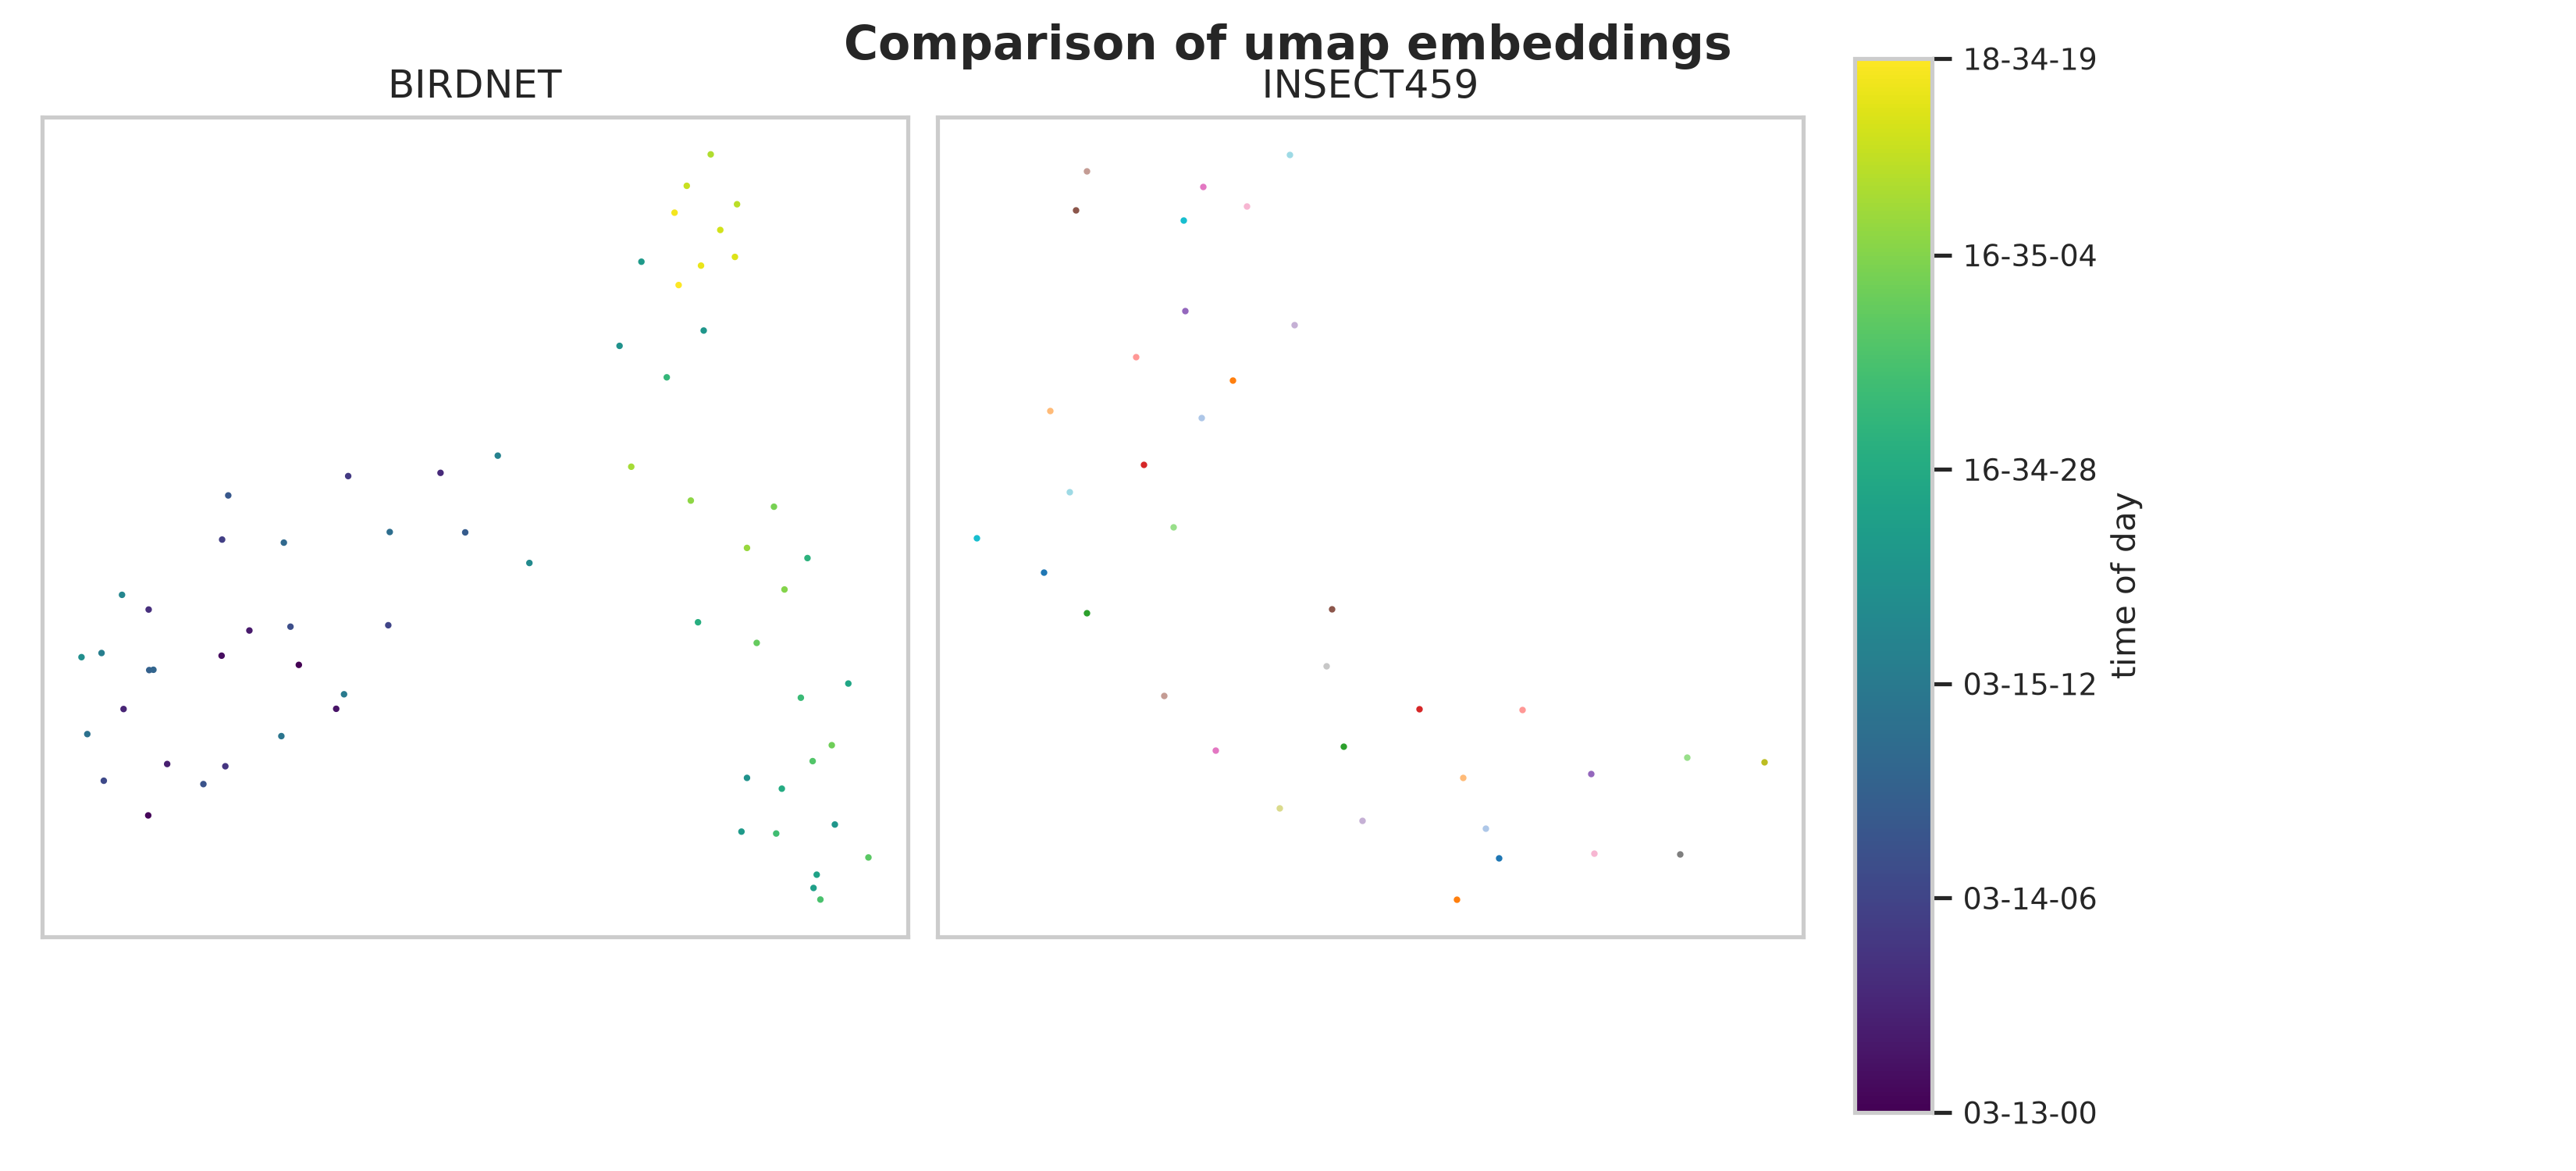

--- comparison_knn_probing_in-bi.png ---


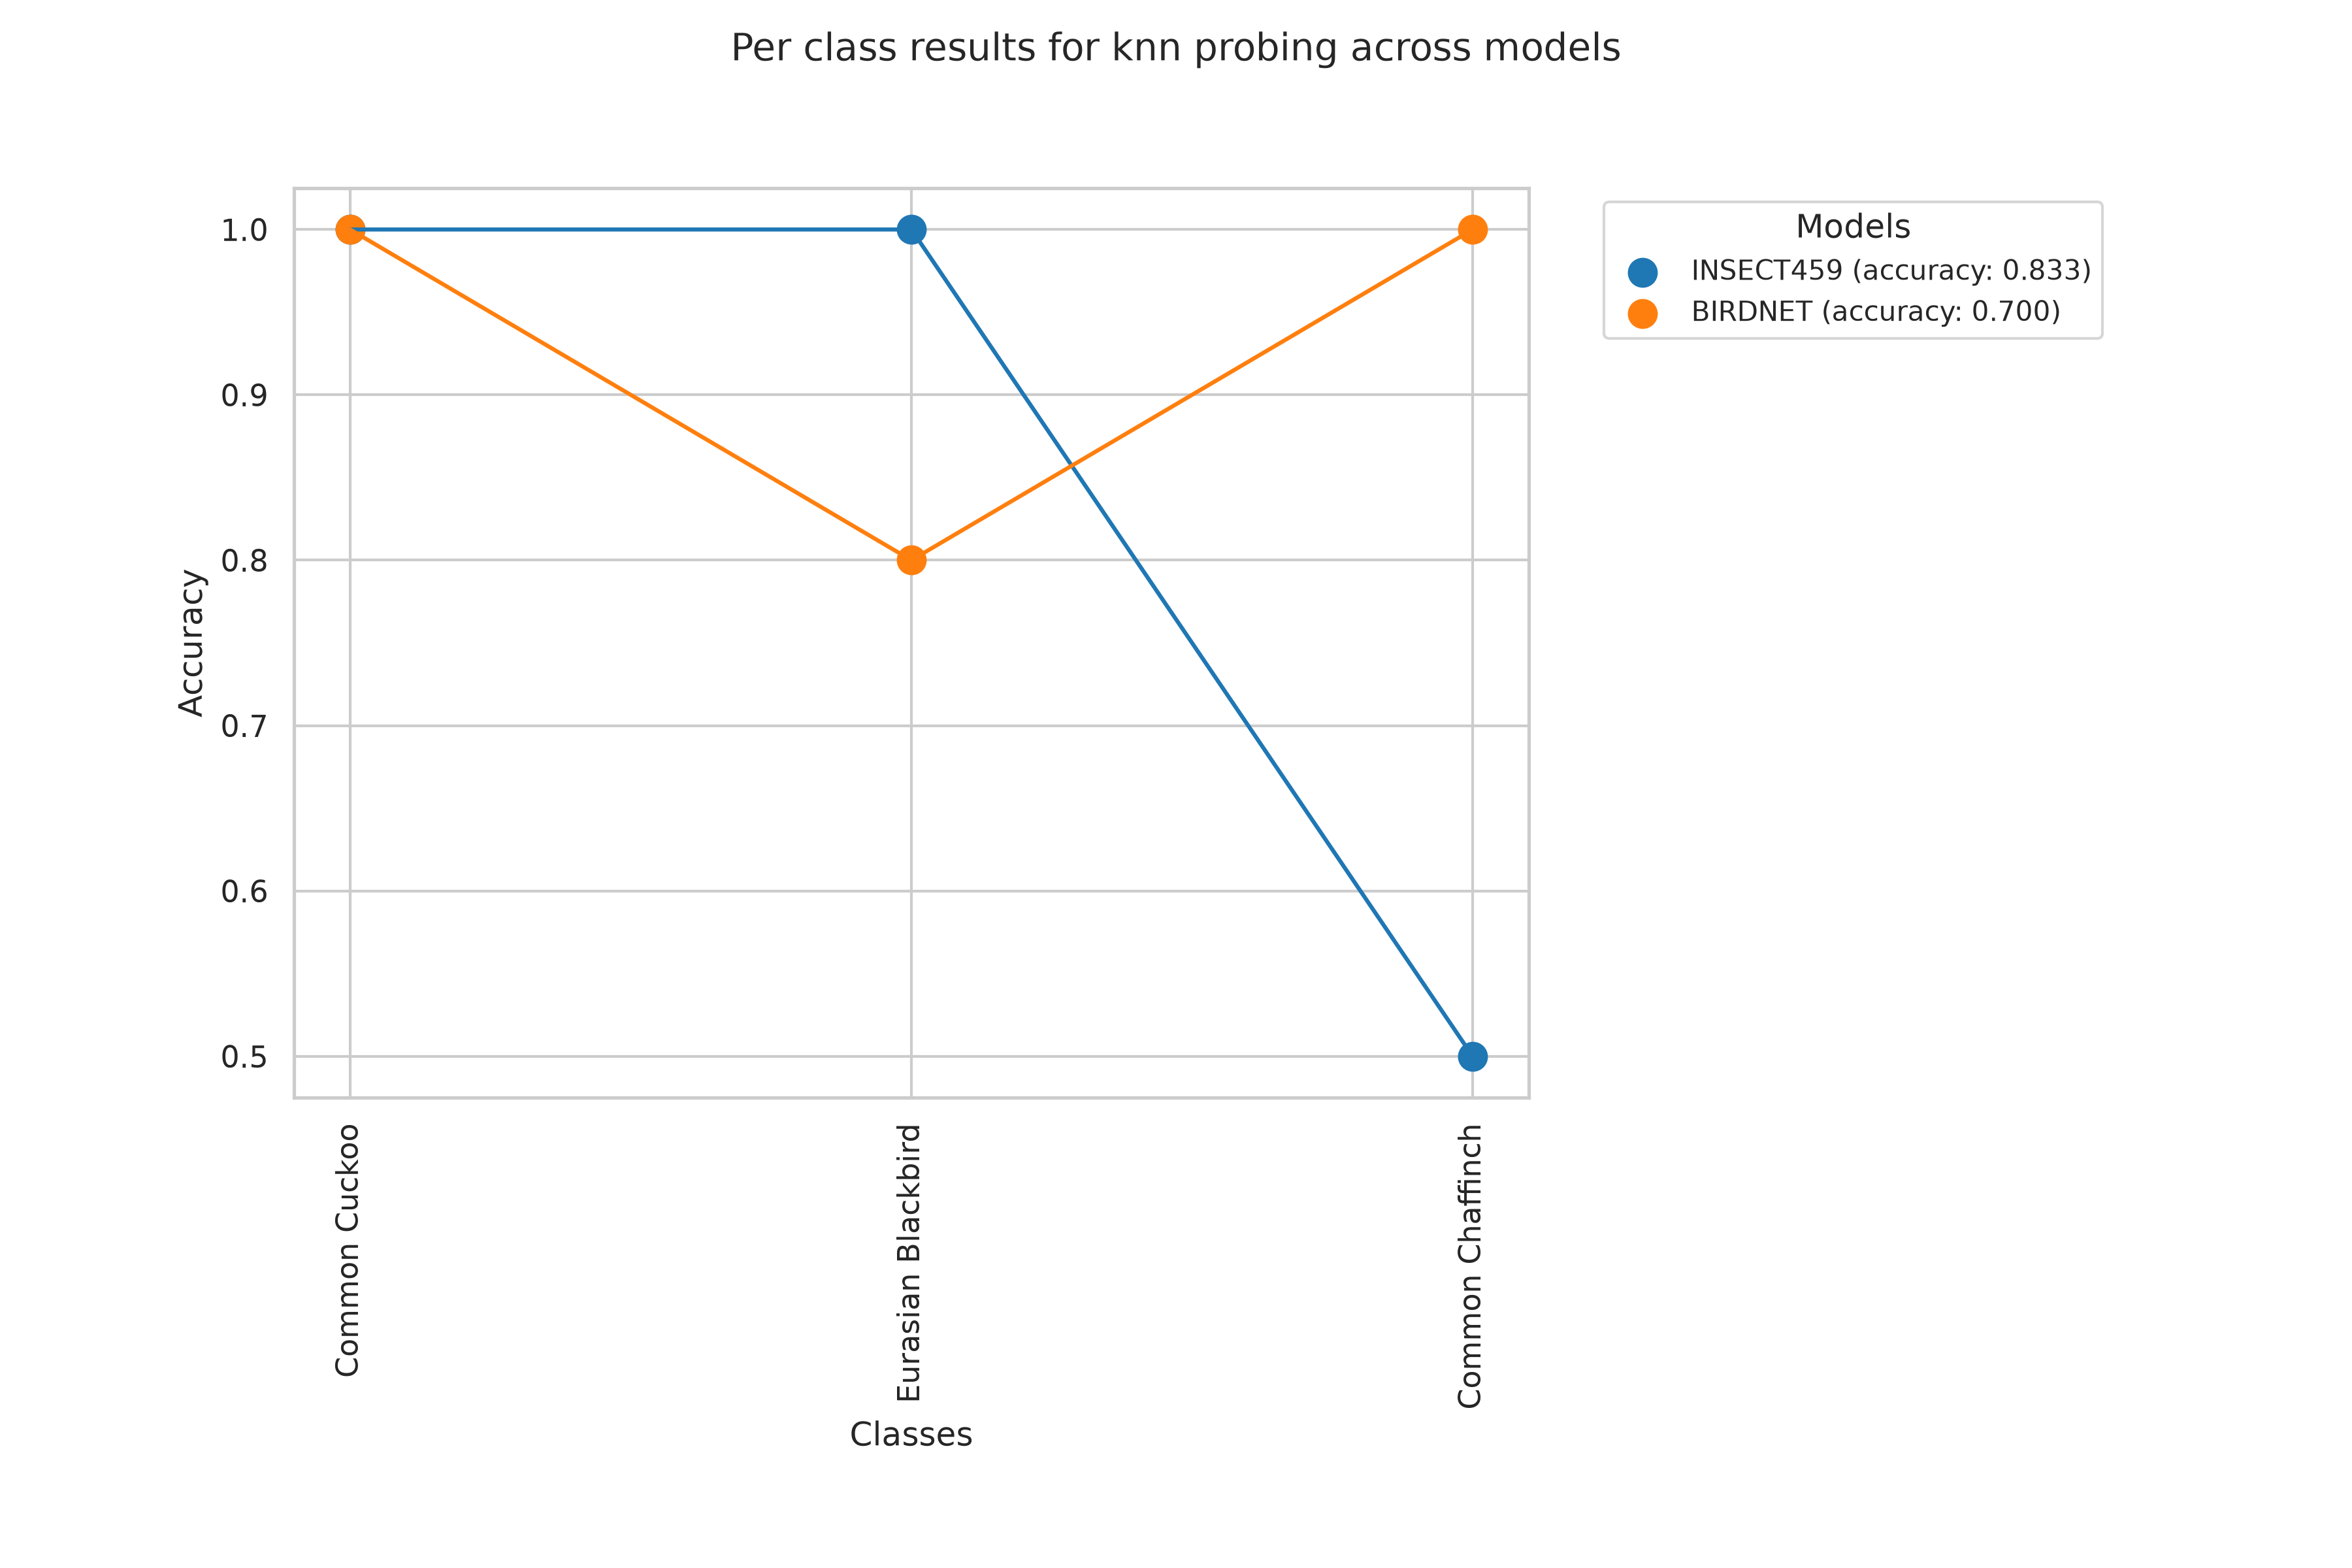

--- comparison_linear_probing_bi-in.png ---


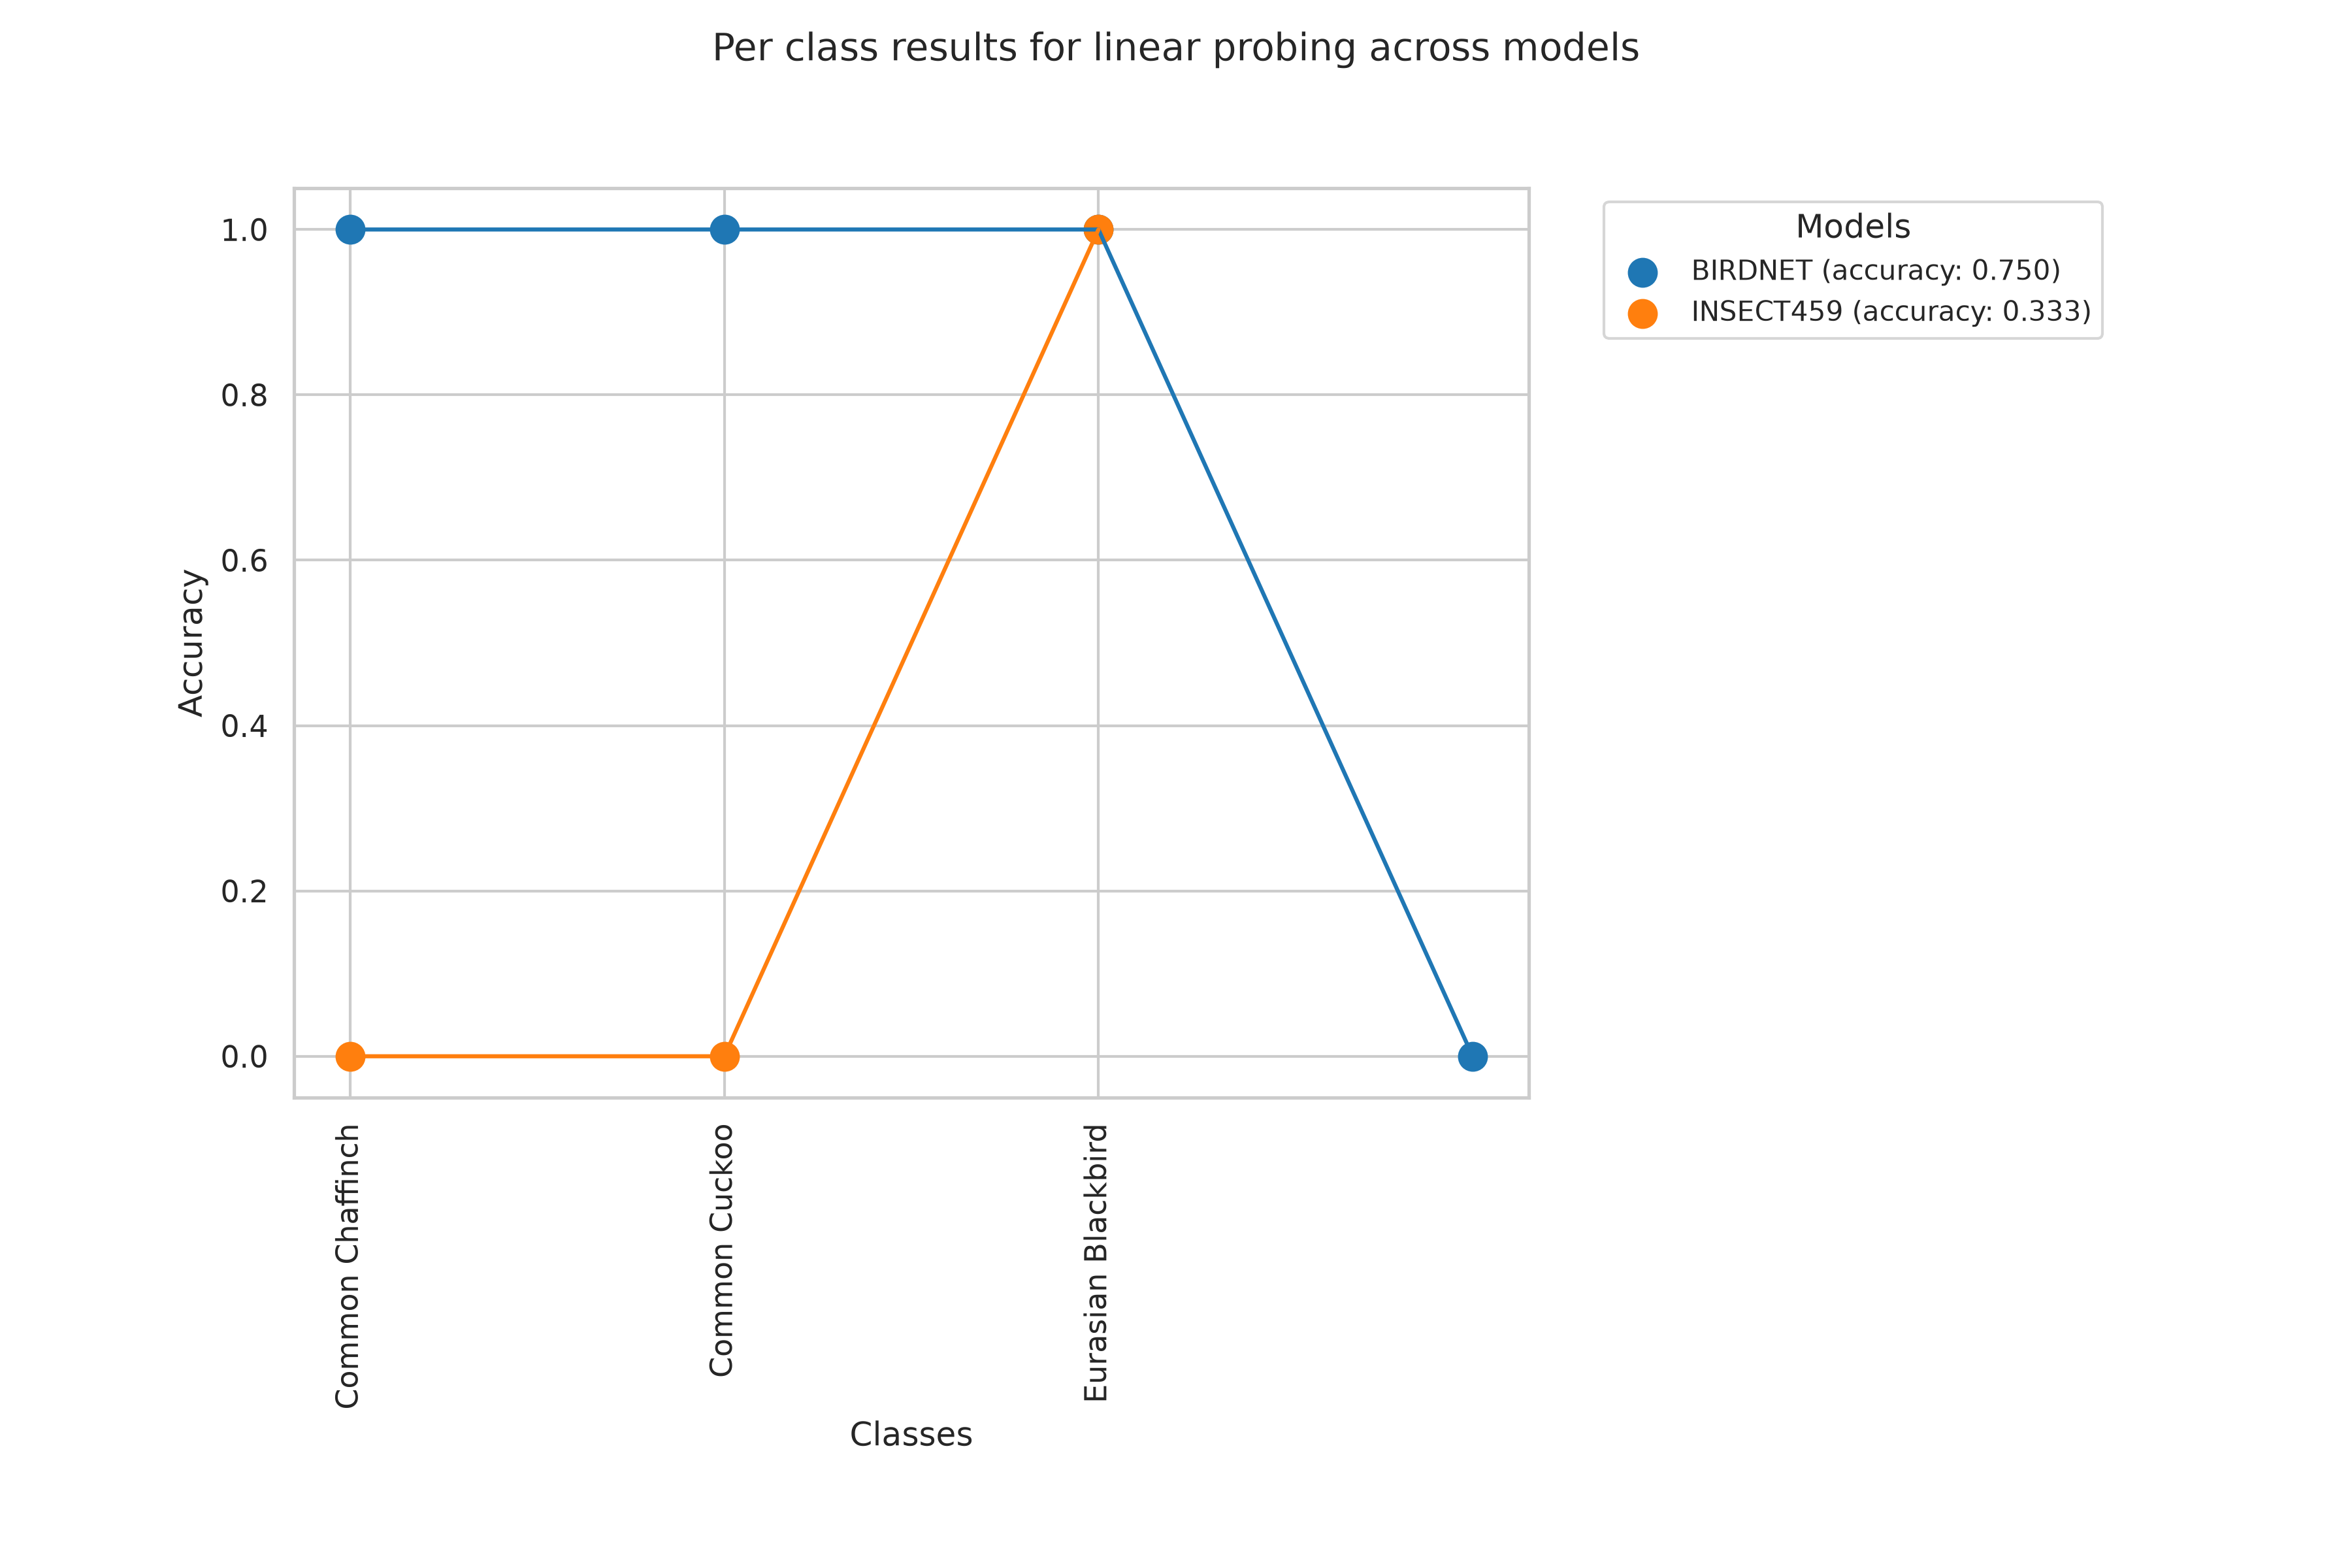

--- overview_metrics_clustering_in-bi.png ---


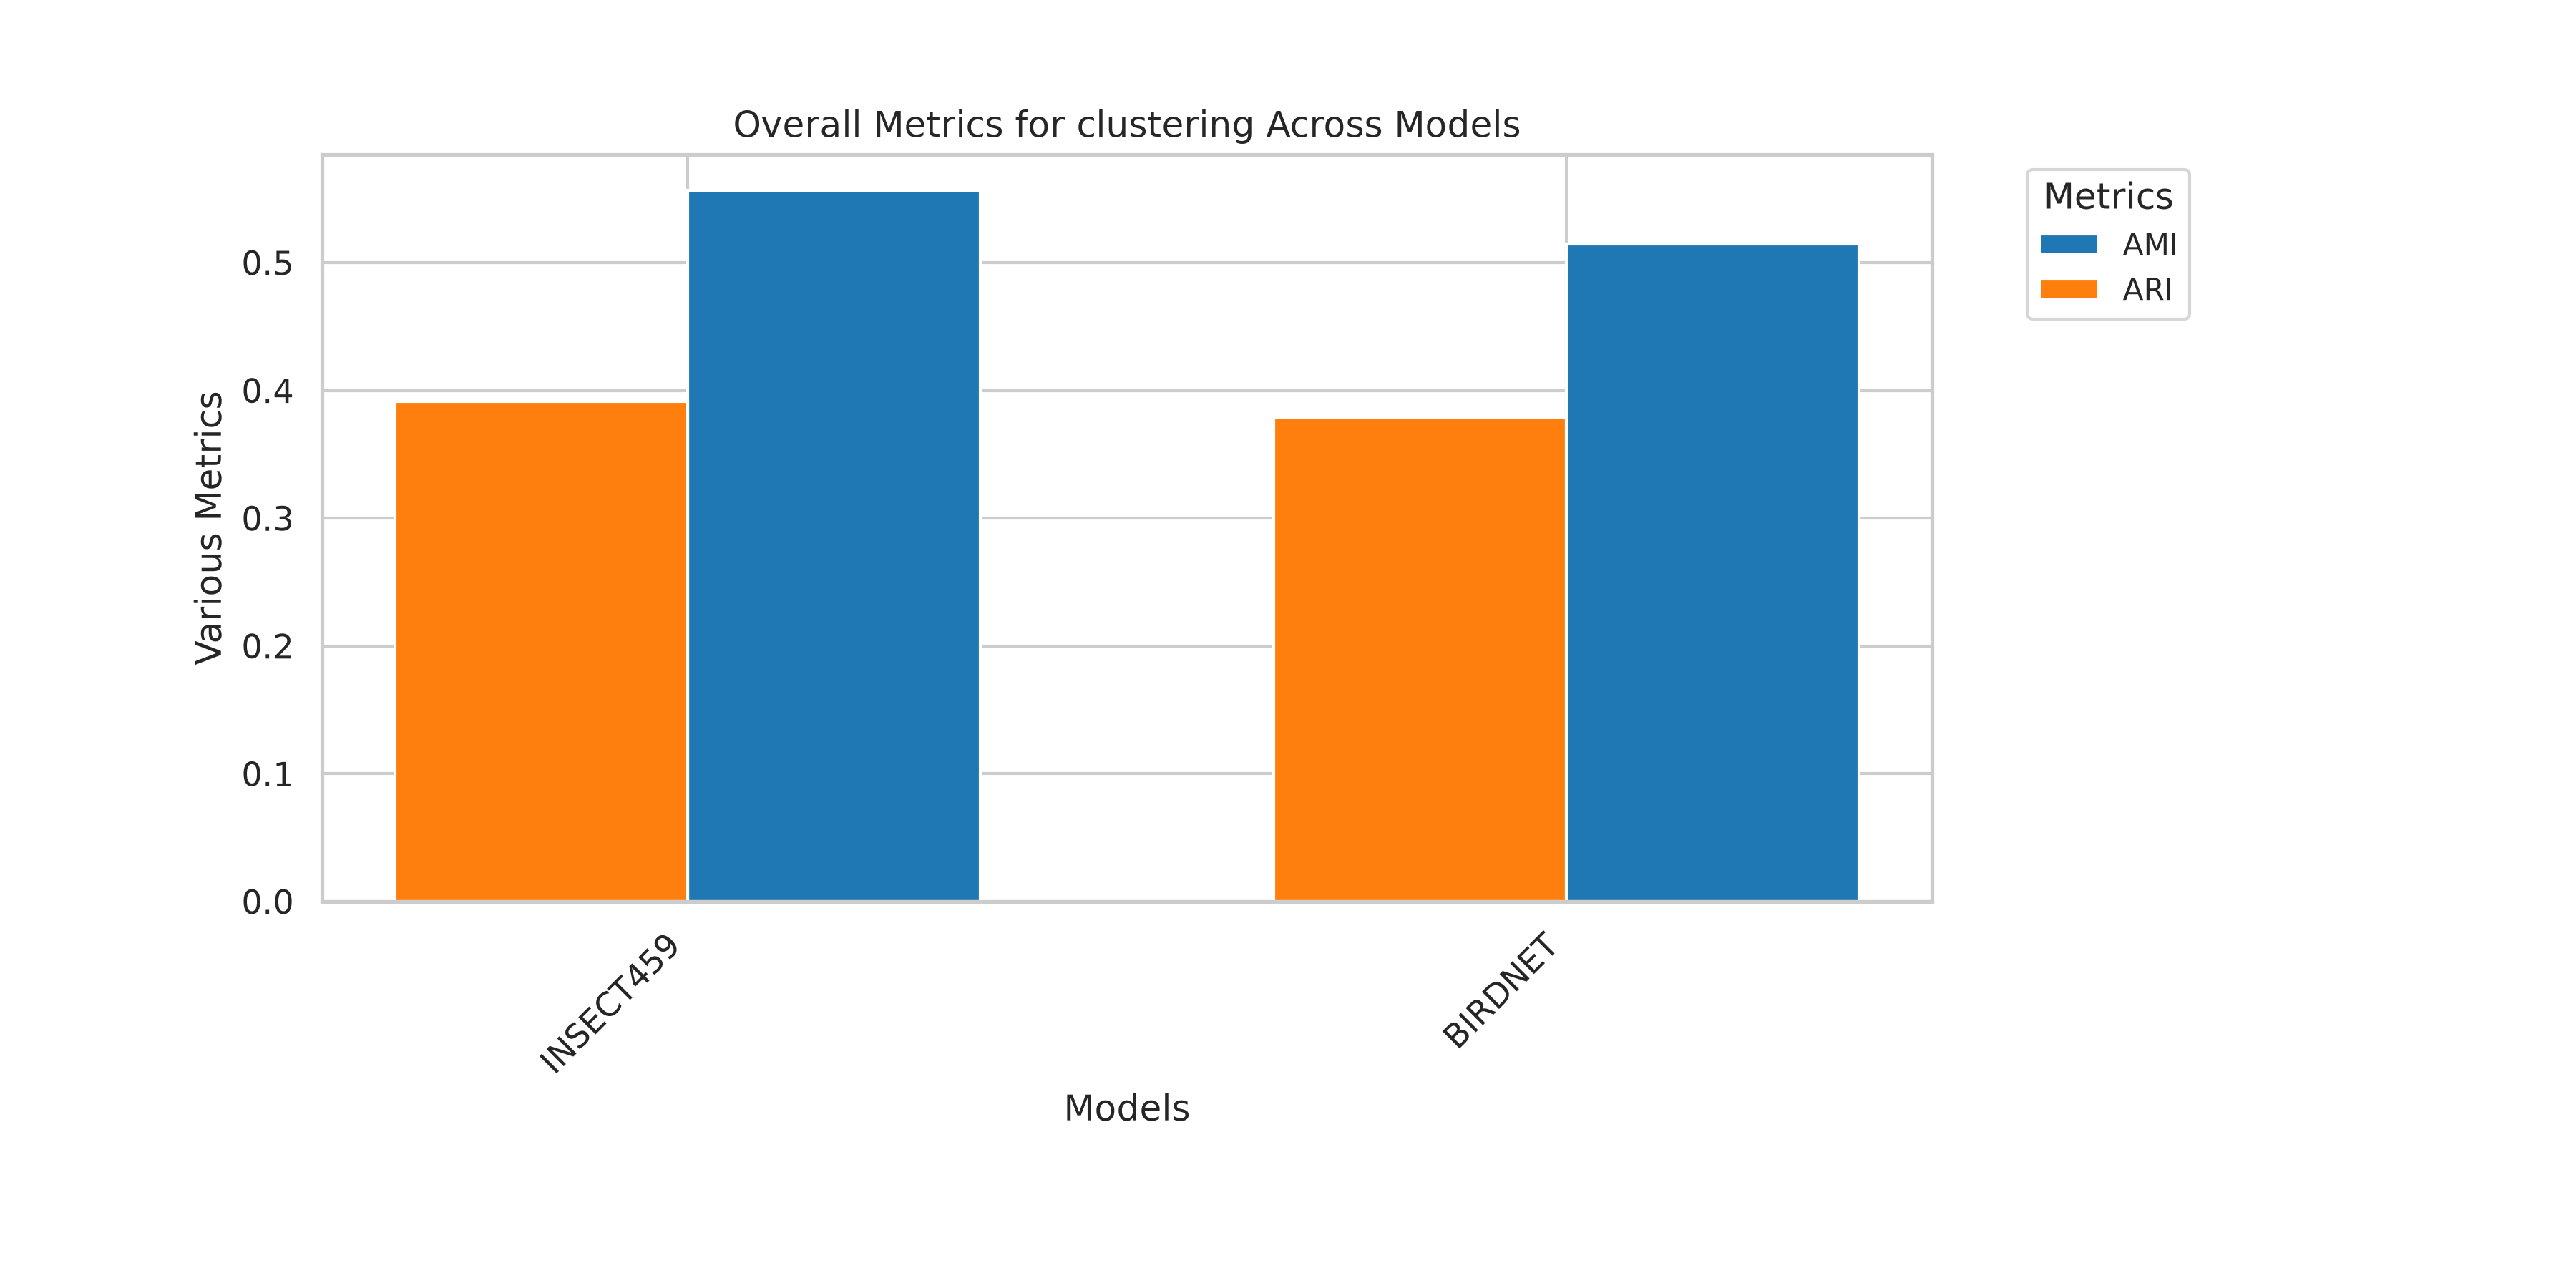

--- overview_metrics_knn_probing_in-bi.png ---


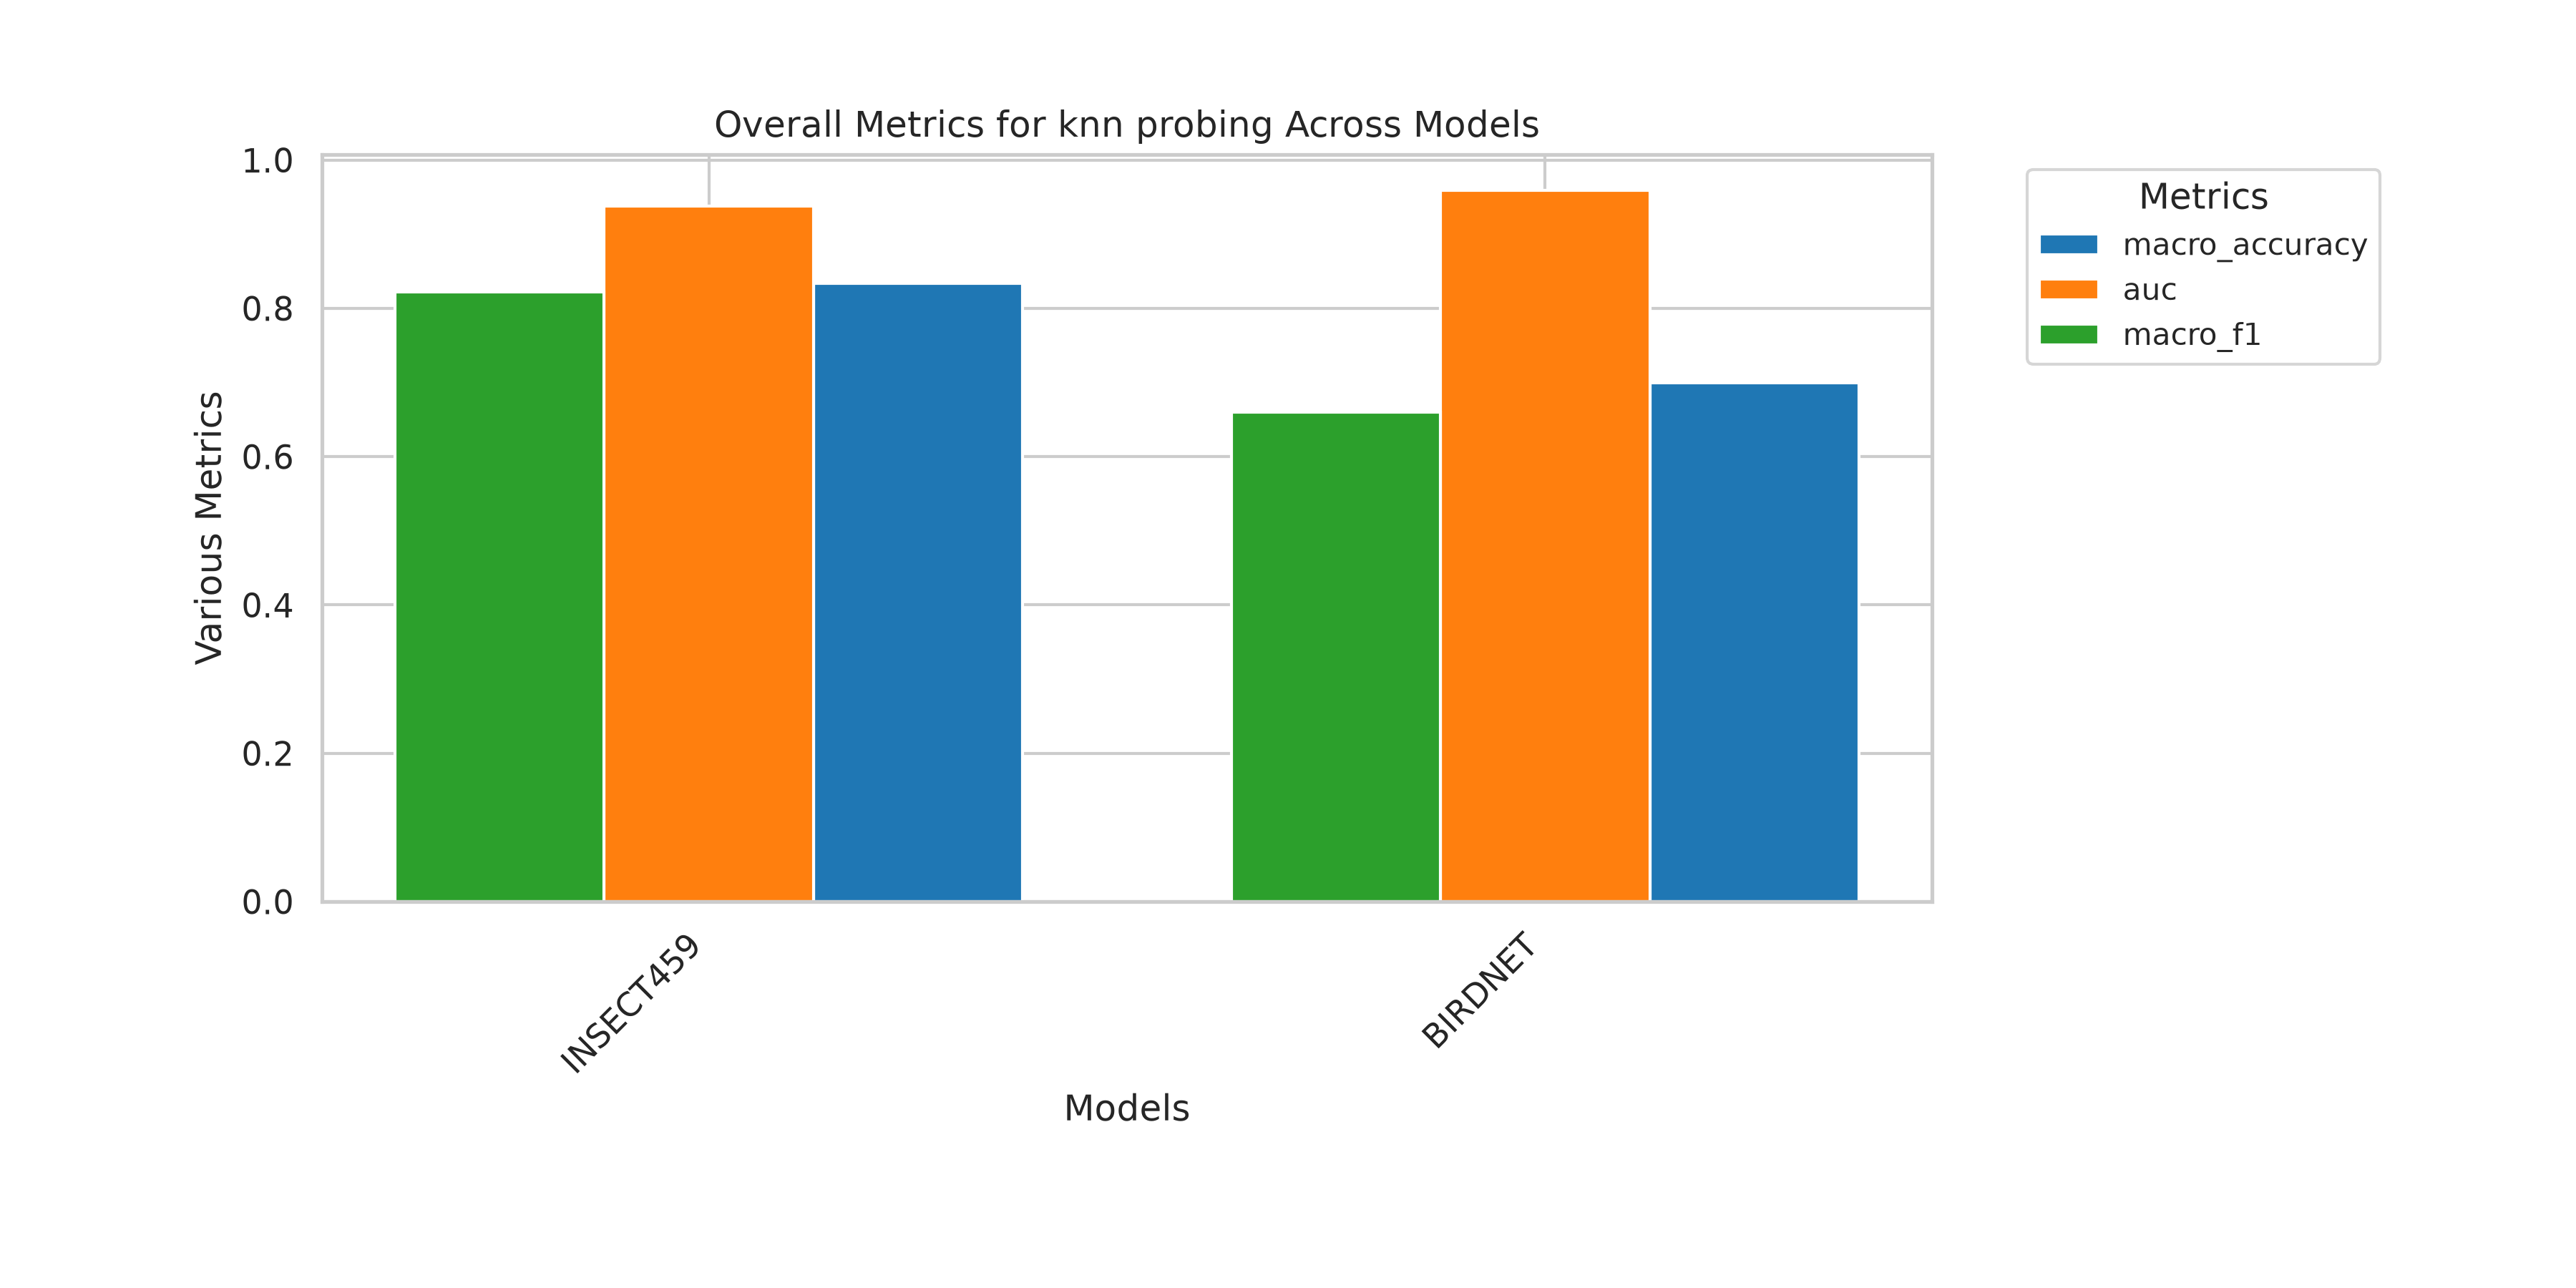

--- overview_metrics_linear_probing_bi-in.png ---


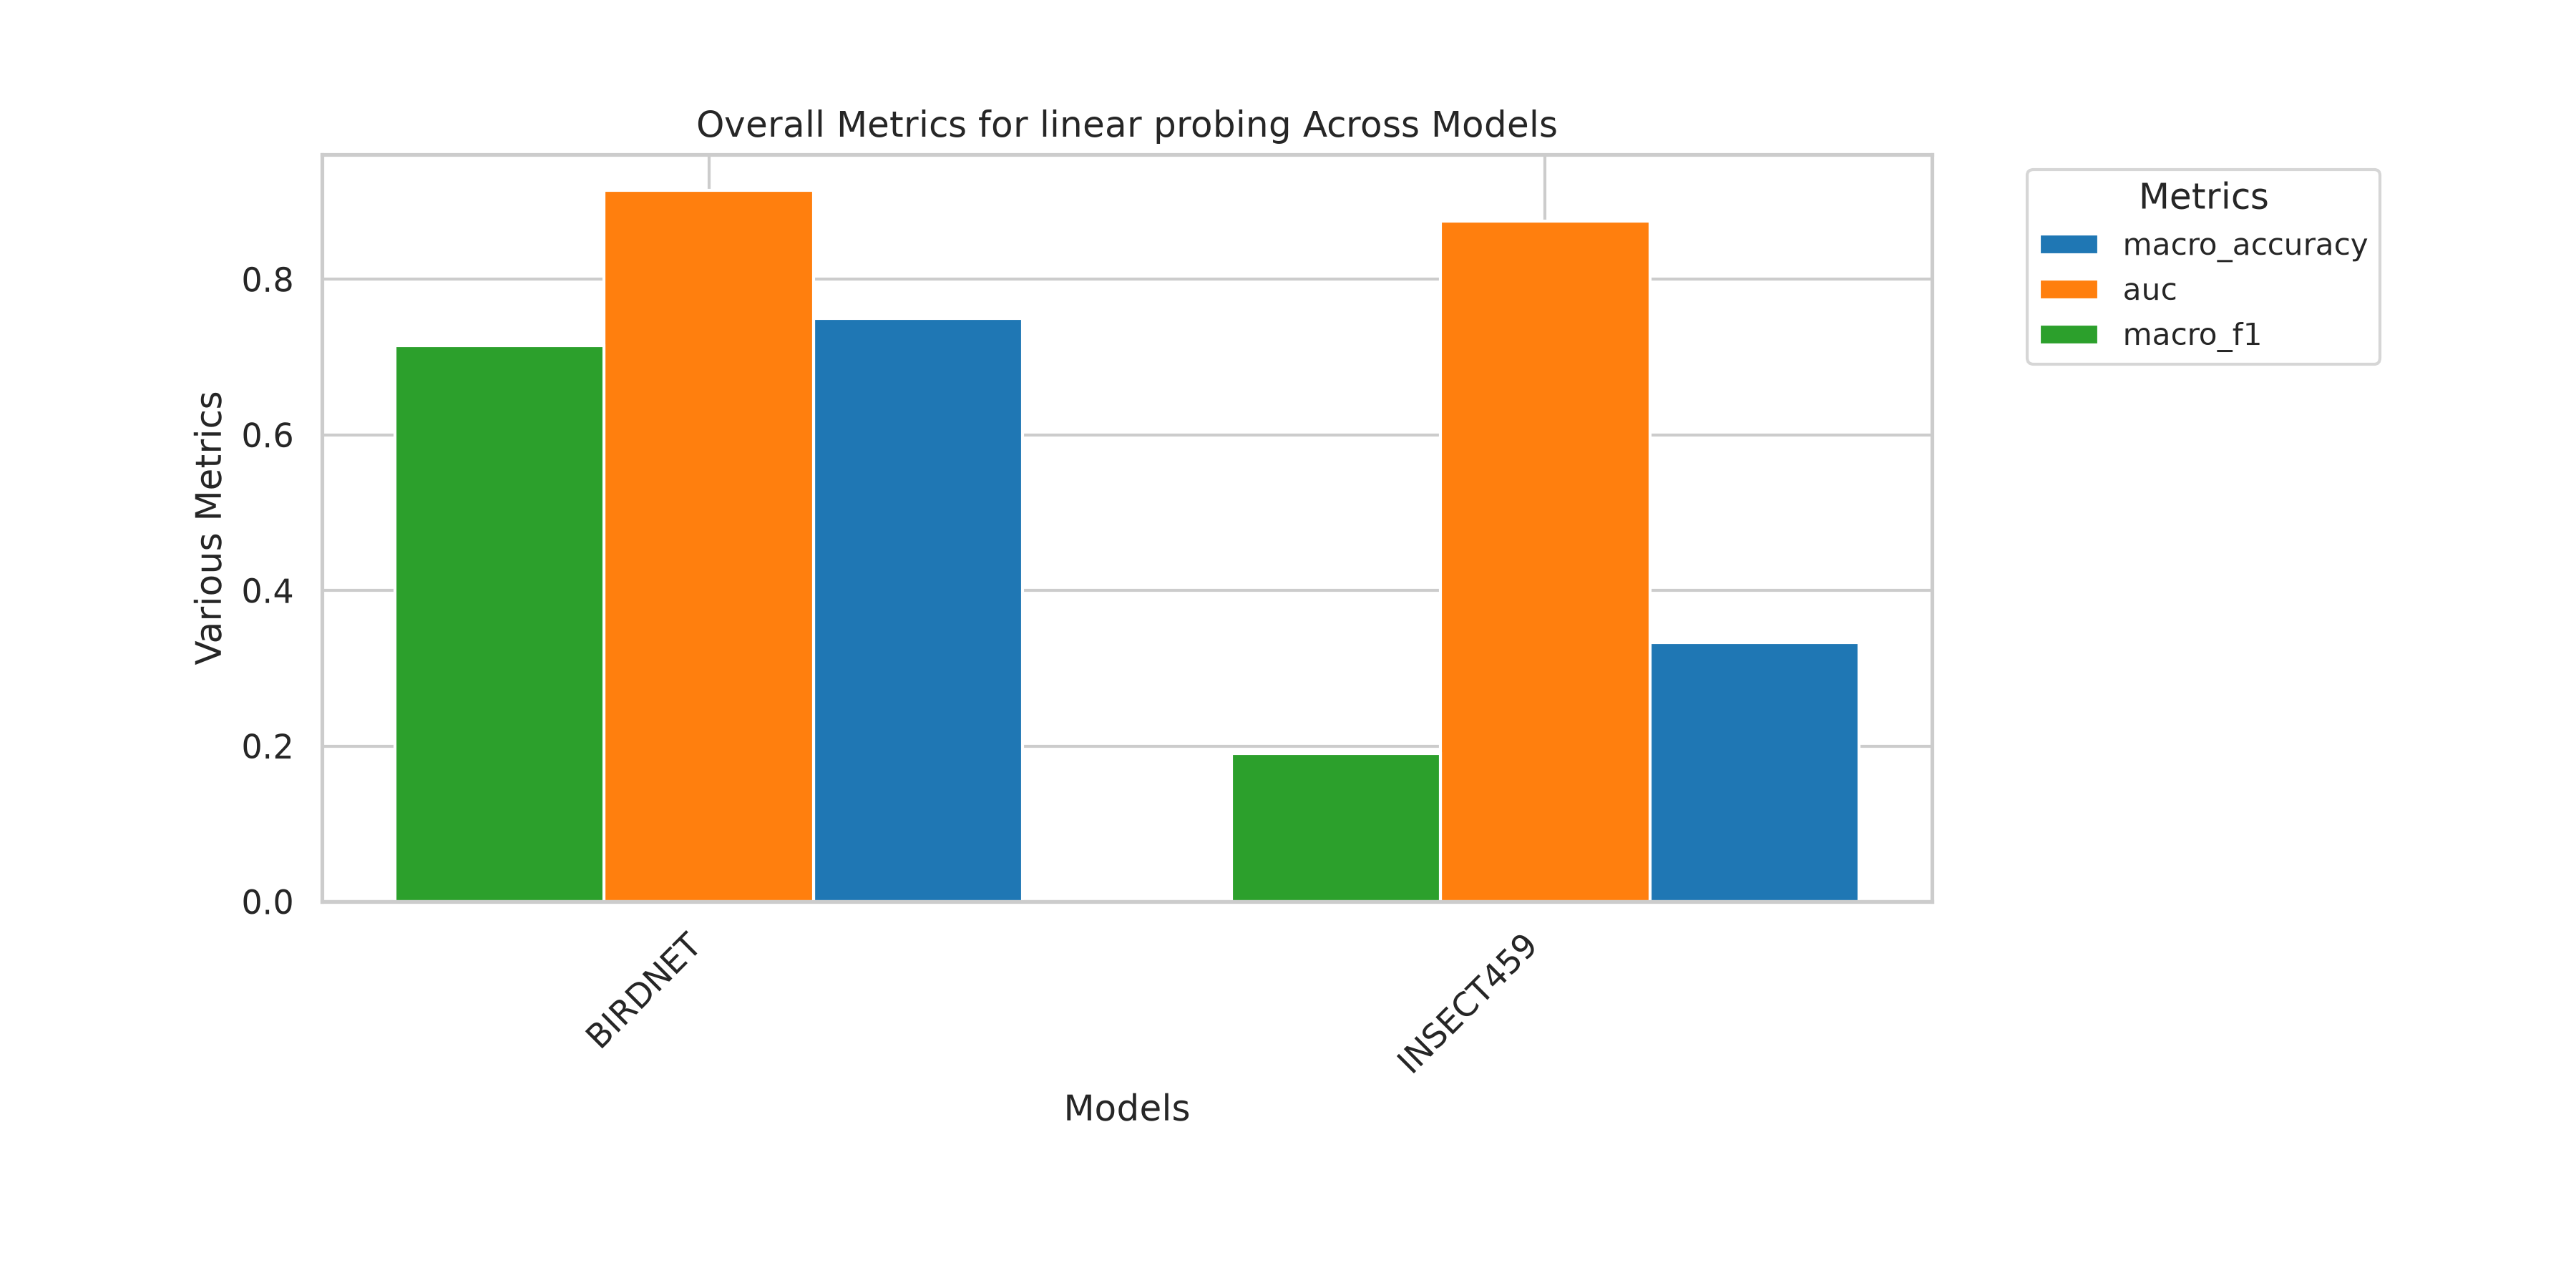

In [26]:
# The overview plots are written to the ``overview`` folder inside the
# results directory. Display all of them at half size.
overview_dir = get_paths('birdnet').plot_path.parent.parent / 'overview'
print('Overview plots in:', overview_dir)
for png in sorted(overview_dir.glob('*.png')):
    print('---', png.name, '---')
    show_half(png)


---
## 14. Dashboard & play

Finally, `visualize_using_dashboard` serves an interactive dashboard for
exploring the embeddings, and `play` runs the entire pipeline in one go. Both
are blocking, so they are shown here as commented-out commands.

In [27]:
# Run the whole pipeline (embedding generation + evaluation) for the models
# configured in bacpipe.config. This is the highest-level entry point.
#
# ``play`` runs everything in one go and, with ``dashboard=True``, also starts
# the blocking dashboard. It also needs a real ``audio_dir``. Uncomment the
# call below and adapt ``audio_dir`` to run it standalone.

bacpipe.play(
    models=['birdnet', 'insect459'],
    audio_dir='bacpipe/tests/test_data',
    dashboard=False,
)


Checking if the selected models require a checkpoint, and if so, if the checkpoint already exists.

birdnet checkpoint exists.

insect459 checkpoint exists.



In [28]:
# Serve the interactive dashboard for the birdnet embeddings.
#
# ``visualize_using_dashboard`` starts a *blocking* web server (it keeps
# running until you interrupt it with Ctrl-C or click close dashboard).

bacpipe.visualize_using_dashboard(
    models=['birdnet'],
    audio_dir='bacpipe/tests/test_data',
    main_results_dir=bacpipe.settings.main_results_dir,
)



There are multiple ground truth files: Since the label does not fit to the label label_column in settings.yaml It is unclear which one bacpipe should use to filter. Therefore the first file str(ground_truth_files[0])='bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/labels/ground_truth_call_type.csv' is selected. 


You have passed a multi-label ground truth array. However for visualization only one label will be displayed.

Using bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/labels/ground_truth_species.csv to calculate the boolean mask to enable filtering of only annotated embeddings.

You have passed a multi-label ground truth array. However for visualization only one label will be displayed.



Launching server at http://localhost:5006


### Passing your own annotations to the dashboard

The `annotations_df` kwarg is optional. Without it (the cell above) the
dashboard describes every point with the labels `bacpipe` created itself:
metadata labels, ground truth, clusterings and classifier predictions.

If you keep additional information about your recordings in a dataframe -- who
annotated a segment, a confidence value, a site name, ... -- pass it as
`annotations_df`. Every column that is not needed for plotting is then shown
next to the spectrogram of a clicked point (and, with
`only_embed_annotations=True`, the dataframe replaces the annotations csv when
the segments to embed are determined).

The rows are matched to the embedded segments on `audiofilename` and `start`
(the same columns as the annotations csv, `start` in seconds from the beginning
of the file), so the values always belong to the point that was clicked, even
if the dataframe is unsorted or covers only part of the recordings. Segments
without a matching row simply show no value. If `audiofilename` and `start` are
missing, the values are attached by position, which requires exactly one row
per embedding. Anything that cannot be aligned is logged as a warning and the
dashboard is served without the extra columns instead of failing.

In [29]:
# Serve the dashboard with your own annotations dataframe.
#
# Blocking, just like the cell above.

import pandas as pd

annotations_df = pd.read_csv('bacpipe/tests/test_data/annotations.csv')
# two columns bacpipe knows nothing about
annotations_df['annotator'] = 'reviewer_1'
annotations_df['recording_site'] = [
    'site_a' if 'FewShot' in name else 'site_b'
    for name in annotations_df.audiofilename
]
print(annotations_df.head())

bacpipe.visualize_using_dashboard(
    models=['birdnet'],
    audio_dir='bacpipe/tests/test_data',
    main_results_dir=bacpipe.settings.main_results_dir,
    annotations_df=annotations_df,
)


There are multiple ground truth files: Since the label does not fit to the label label_column in settings.yaml It is unclear which one bacpipe should use to filter. Therefore the first file str(ground_truth_files[0])='bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/labels/ground_truth_call_type.csv' is selected. 


You have passed a multi-label ground truth array. However for visualization only one label will be displayed.

Using bacpipe_results/using_different_bacpipe_functions/test_data/evaluations/birdnet/labels/ground_truth_species.csv to calculate the boolean mask to enable filtering of only annotated embeddings.

You have passed a multi-label ground truth array. However for visualization only one label will be displayed.



                              audiofilename  start  end     label:species  \
0  audio/FewShot/CHE_01_20190101_163410.wav      0    5        Tree Pipit   
1  audio/FewShot/CHE_01_20190101_163410.wav      5   10        Tree Pipit   
2  audio/FewShot/CHE_01_20190101_163410.wav     10   15  Eurasian Kestrel   
3  audio/FewShot/CHE_01_20190101_163410.wav     15   20  Common Chaffinch   
4  audio/FewShot/CHE_01_20190101_163410.wav     20   25  Common Chaffinch   

  label:call_type   annotator recording_site  
0               A  reviewer_1         site_a  
1               A  reviewer_1         site_a  
2               A  reviewer_1         site_a  
3               A  reviewer_1         site_a  
4               A  reviewer_1         site_a  


The port 5006 is already in use. This is most likely the case because you already have a dashboard open. There is a exit button in the bottom left of the dashboard. If this was intentional and you want to open multiple dashboards at once, ignore this message.


Launching server at http://localhost:5007
